In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
telco_base_data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
telco_base_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
telco_base_data[telco_base_data["tenure"] == 0].shape

(11, 21)

In [ ]:
telco_base_data.shape

(7043, 21)

In [ ]:
telco_base_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
telco_base_data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [ ]:
telco_base_data["TotalCharges"] = pd.to_numeric(telco_base_data["TotalCharges"] , errors = 'coerce')

In [ ]:
telco_base_data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Senior Citizen attribute is actually categorical so it is not appropriate for it to be in this insight.


75% of the people have the tenure less than 55 months
And 50% of the people have tenure of around 29 months.

Average monthly charges were seen to be around USD64.76  and around 25% people pay more than USD89.85.

Average TotalCharges were USD 2283.3 and more than 25% people pay more than USD 3794.73 in total.

# Now Lets see number of people churning and number that are not

Text(0.5, 1.02, 'Count of target Variable per category')

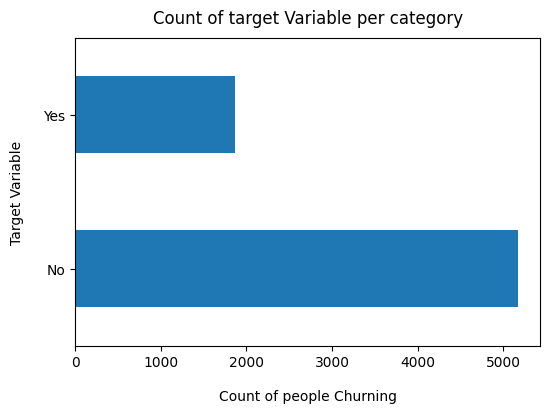

In [ ]:
telco_base_data["Churn"].value_counts().plot(kind='barh', figsize=(6,4))
plt.ylabel("Target Variable", labelpad=14)
plt.xlabel("Count of people Churning", labelpad=14)
plt.title("Count of target Variable per category", y=1.02)

Churner vs non churner in percentage

In [ ]:
100*telco_base_data["Churn"].value_counts()/len(telco_base_data["Churn"])

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

In [ ]:
telco_base_data["Churn"].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

We can see that the data is highly imbalanced. Ratio = 73:27



In [ ]:
telco_base_data.info(verbose=True) #Verbose is used just to make the output look nicer

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
telco_base_data.isna().sum() #Remember isna and isnull are the same

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

We can see their are 11 null values present in TotalCharges. As out of 7043 values only 11 null values are there so we can simply fill the entries with mean. or can simply drop these row as they wont cause a significance change in our model.

In [ ]:
#Making the df instance smaller as it is tough for writing again and again
telco_df = telco_base_data.copy()

In [ ]:
#First checking where we can see null values
telco_df.loc[telco_df['TotalCharges'].isna() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
#Testing both ways
#1)Dropping the rows
telco_df1 = telco_df.dropna(how='any')

In [ ]:
telco_df1.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Now we dont have any missing values from method 1

In [ ]:
#Filling the rows with mean
telco_df2 = telco_df.fillna(value=telco_df.TotalCharges.mean())

In [ ]:
telco_df2.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

With filling also we dont have any missing values now.

So we proceed further(For now we will proceed with telco_df2 after that we can also analyze wih telco_df1 as well)

# Now we will analyze tenure column

From describe we can see tenure has range from 0 to 72 months where mean is 32.3 months and  50% people have tenure less than 29 months.

As there are so many various tenure values so we will simply group tenure values as 0-12 months, 13-24 months , 25-36 , 37-48 , 49-60 , 60-72 months. ie in bins of 12 months. For a better understanding.

In [ ]:
telco_df2.tenure.max()

72

In [ ]:
labels = ["{0} - {1}".format(i , i+11) for i in range(1,72,12)]

telco_df2["tenure_groups"] = pd.cut(telco_df2.tenure, range(1, 80, 12), right = False,labels = labels)

In [ ]:
#Lets see what bins have been created
telco_df2["tenure_groups"].value_counts()

1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: tenure_groups, dtype: int64

Now we need to remove irrelevant columns

In [ ]:
#Removing customerID and tenure columns as we have already made a new tenure_groups column and customerID is not required as it is irrelevant
telco_df2.drop(columns = ['customerID', 'tenure'], axis = 1, inplace=True)
telco_df2.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_groups
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


#Univariate Analysis

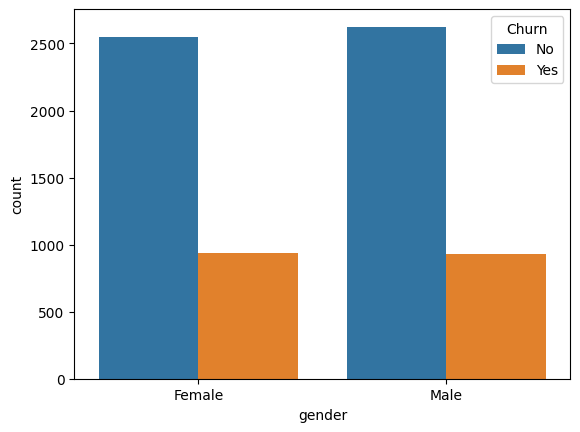

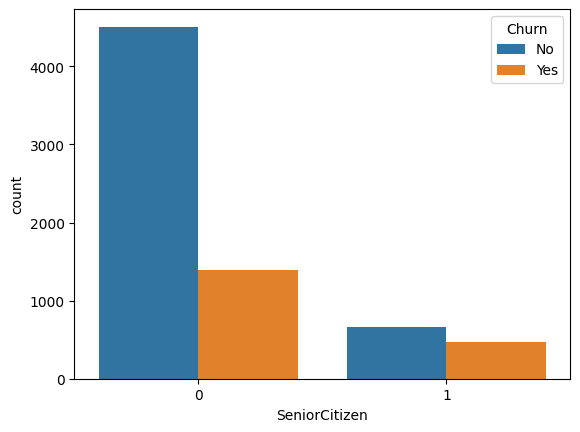

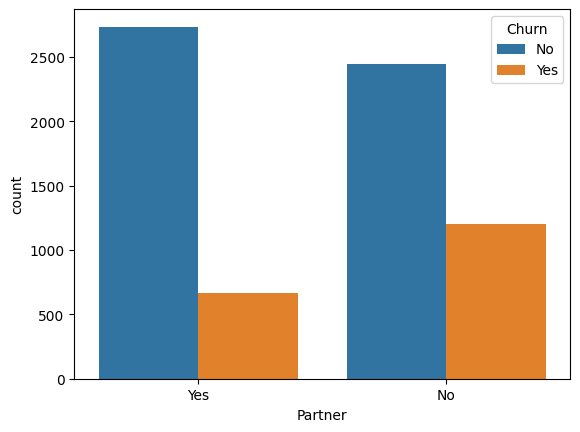

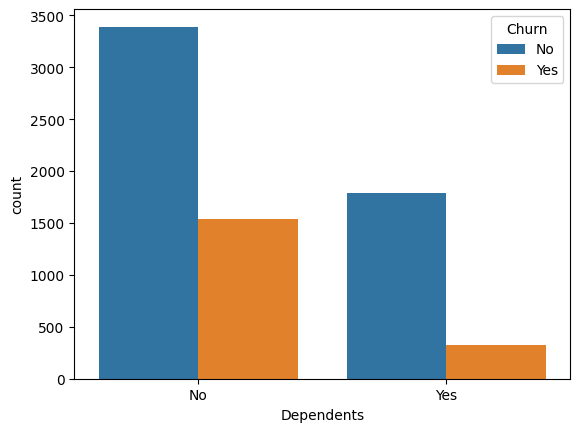

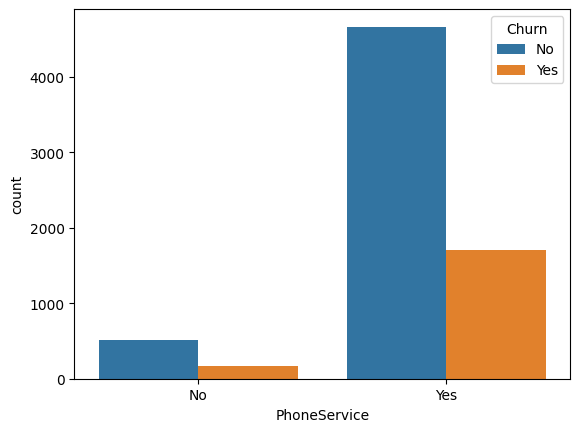

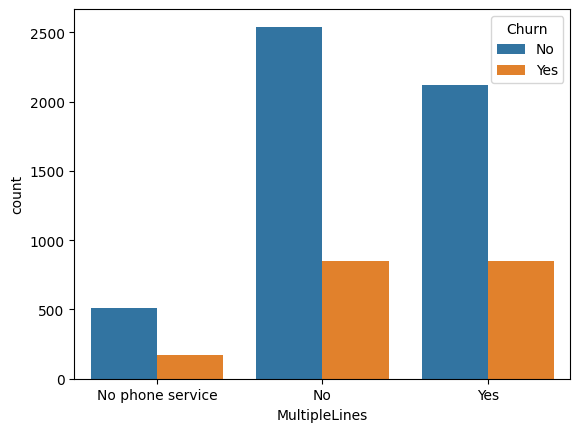

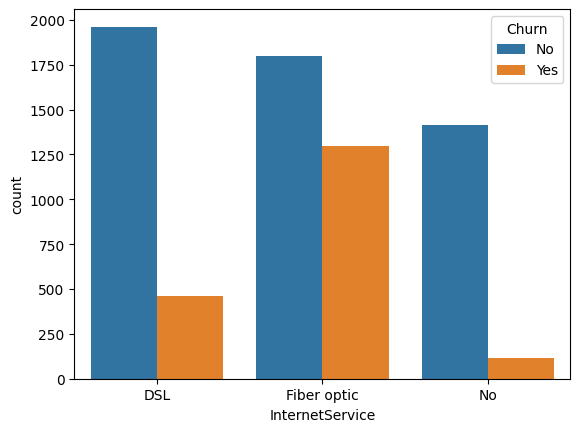

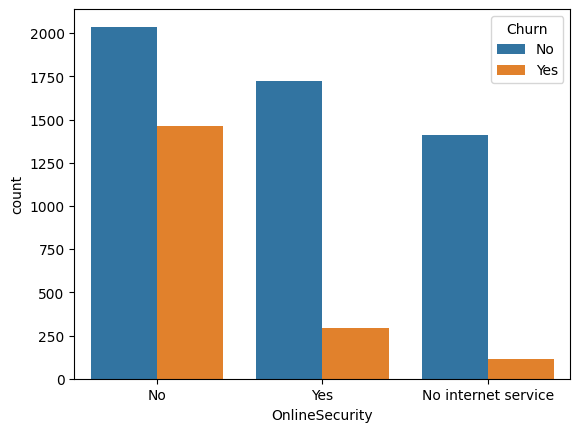

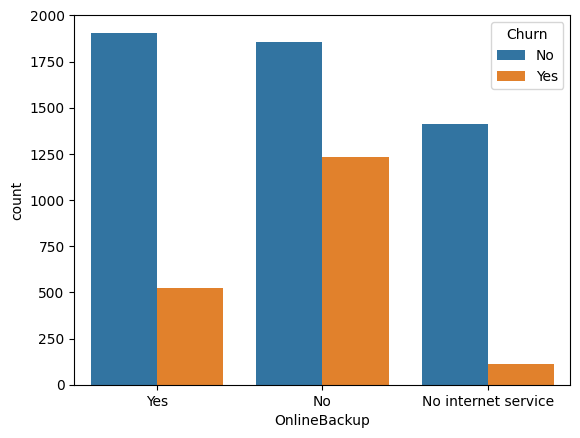

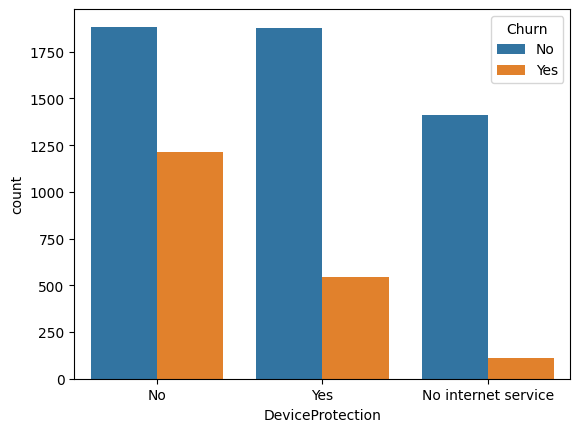

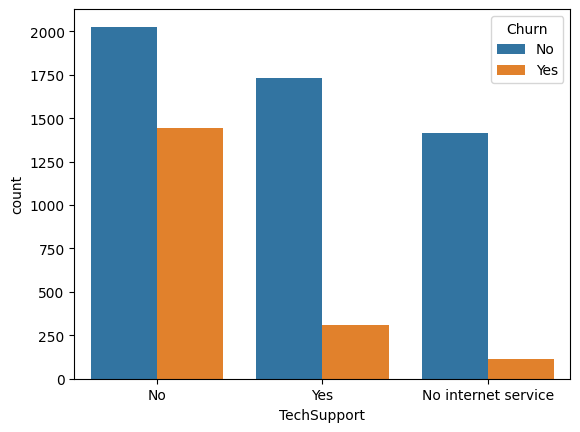

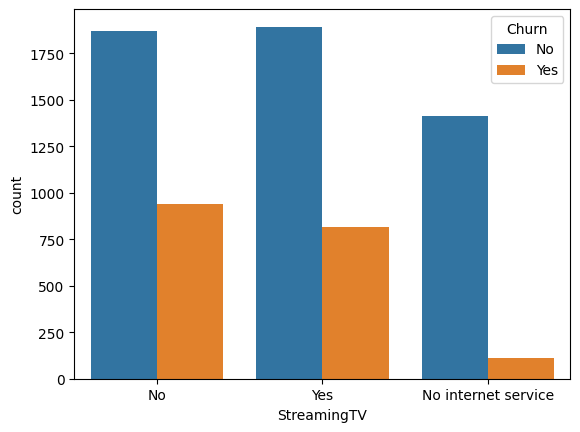

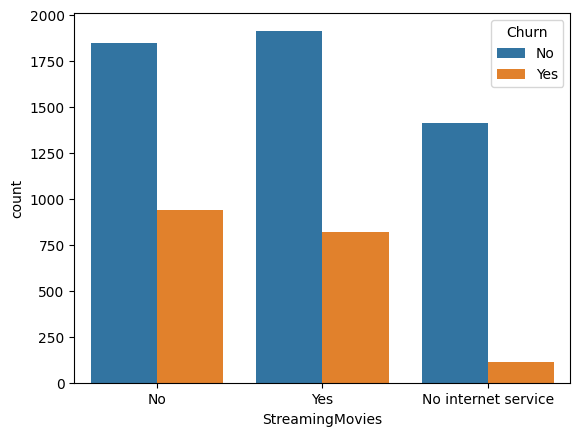

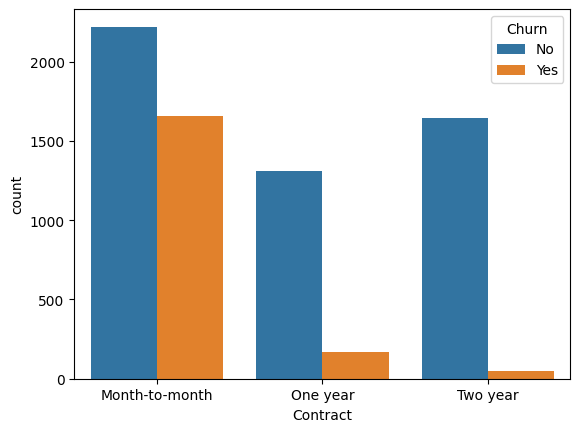

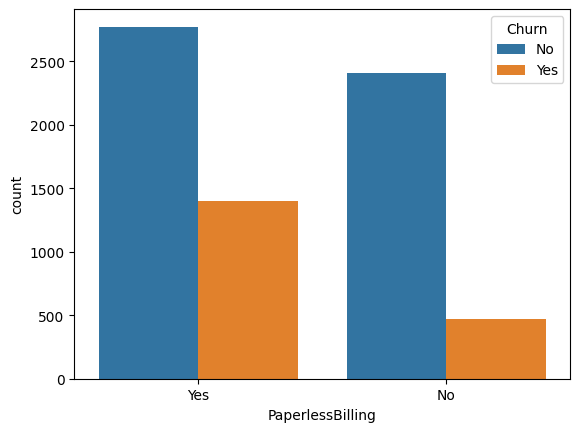

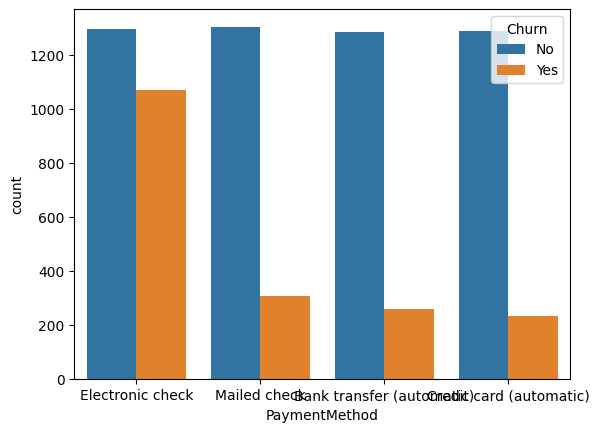

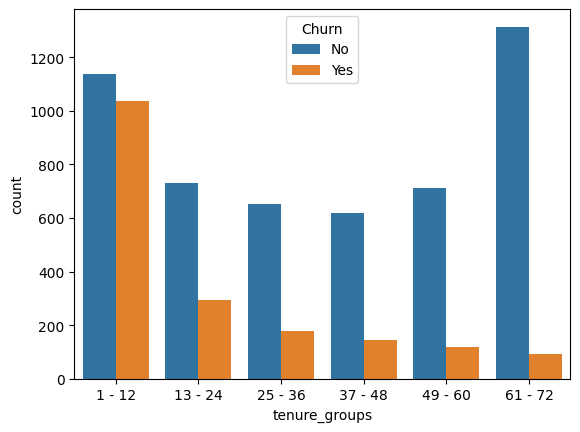

In [ ]:
for i, predictor in enumerate(telco_df2.drop(columns=['Churn' , 'TotalCharges' , 'MonthlyCharges'])): #Iterating all coloumns except churn,totalcharges,monthlycharges
  plt.figure(i)
  sns.countplot(data=telco_df2, x=predictor, hue='Churn')

Converting "Churn" variable into binary numeric variable

In [ ]:
telco_df2["Churn"] = np.where(telco_df2.Churn == "Yes" ,1,0)

In [ ]:
telco_df2.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_groups
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


Now Converting all categorical variables into dummy variables using One Hot Encoding

In [ ]:
telco_df_dummies = pd.get_dummies(telco_df2)
telco_df_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_groups_1 - 12,tenure_groups_13 - 24,tenure_groups_25 - 36,tenure_groups_37 - 48,tenure_groups_49 - 60,tenure_groups_61 - 72
0,0,29.85,29.85,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56.95,1889.50,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53.85,108.15,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42.30,1840.75,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70.70,151.65,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


Lets analyze the relationship between monthly charges and total charges. This would give us a great insight. We use lmplot for this as it is a great for analysing relationship between two variables.

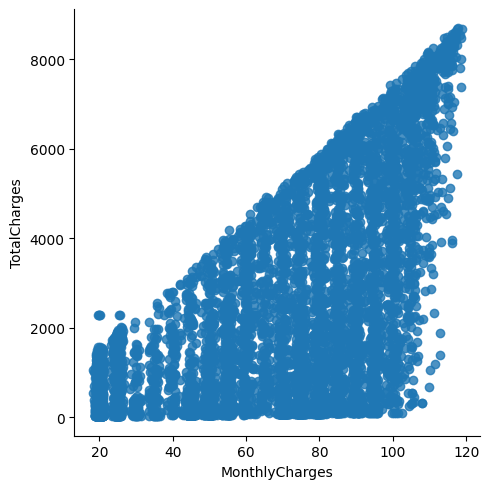

In [ ]:
sns.lmplot(data=telco_df_dummies , x='MonthlyCharges',y='TotalCharges', fit_reg=False)

We can see a high correlation between monthly charges and total charges which is as expected.

# Now lets find Churn by Monthly and Total Charges.

Text(0.5, 1.0, 'Monthly charges by churn')

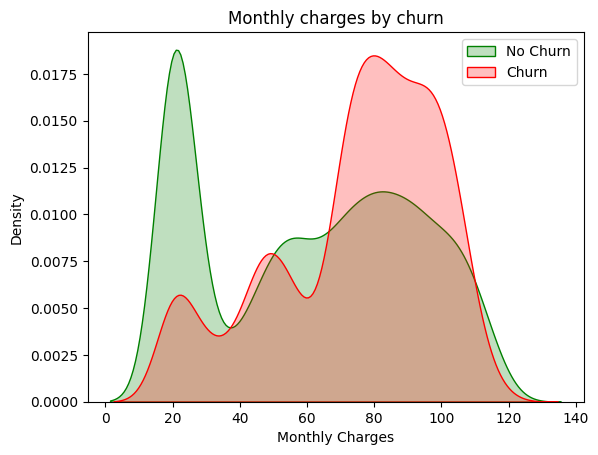

In [ ]:
ch = sns.kdeplot(telco_df_dummies.MonthlyCharges[(telco_df_dummies["Churn"]==0)]
                 , color='Green' , fill=True)
ch = sns.kdeplot(telco_df_dummies.MonthlyCharges[(telco_df_dummies["Churn"]==1)]
                 , ax = ch, color='Red', fill=True) #fill is basically shade here

ch.legend(["No Churn" , "Churn"], loc = 'upper right')
ch.set_ylabel('Density')
ch.set_xlabel('Monthly Charges')
ch.set_title('Monthly charges by churn')

We get a great insight here that the churn is increasing when the monthly charges are high.

Text(0.5, 1.0, 'Total charges by churn')

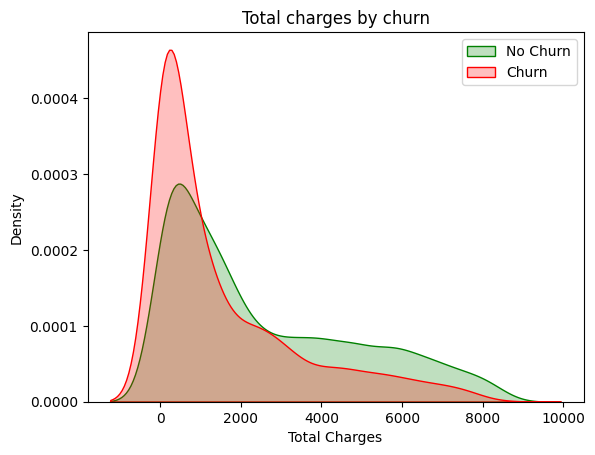

In [ ]:
tot = sns.kdeplot(telco_df_dummies.TotalCharges[(telco_df_dummies["Churn"]==0)]
                 , color='Green' , fill=True)
tot = sns.kdeplot(telco_df_dummies.TotalCharges[(telco_df_dummies["Churn"]==1)]
                 , ax = tot, color='Red', fill=True) #fill is basically shade here

tot.legend(["No Churn" , "Churn"], loc = 'upper right')
tot.set_ylabel('Density')
tot.set_xlabel('Total Charges')
tot.set_title('Total charges by churn')

**Major insight** we are getting here is that when Total Charges are less then we see huge rise in churn. When Total Charges are increasing we see a decline in churn. This decline could be because these customers are  loyal.

If we look at all 3 factors ie Tenure, MonthlyCharge, TotalCharge combined. We see a clear picture that **Higher Monthly Charge** at **Small Tenure** leads to **Low Total Charge**.

Hence all these 3 factors ie **Higher Monthly Charge**,  **Small Tenure**,  **Low Total Charge** leads to **High Churn**.

# Build correlation of all predictors with churn

<Axes: >

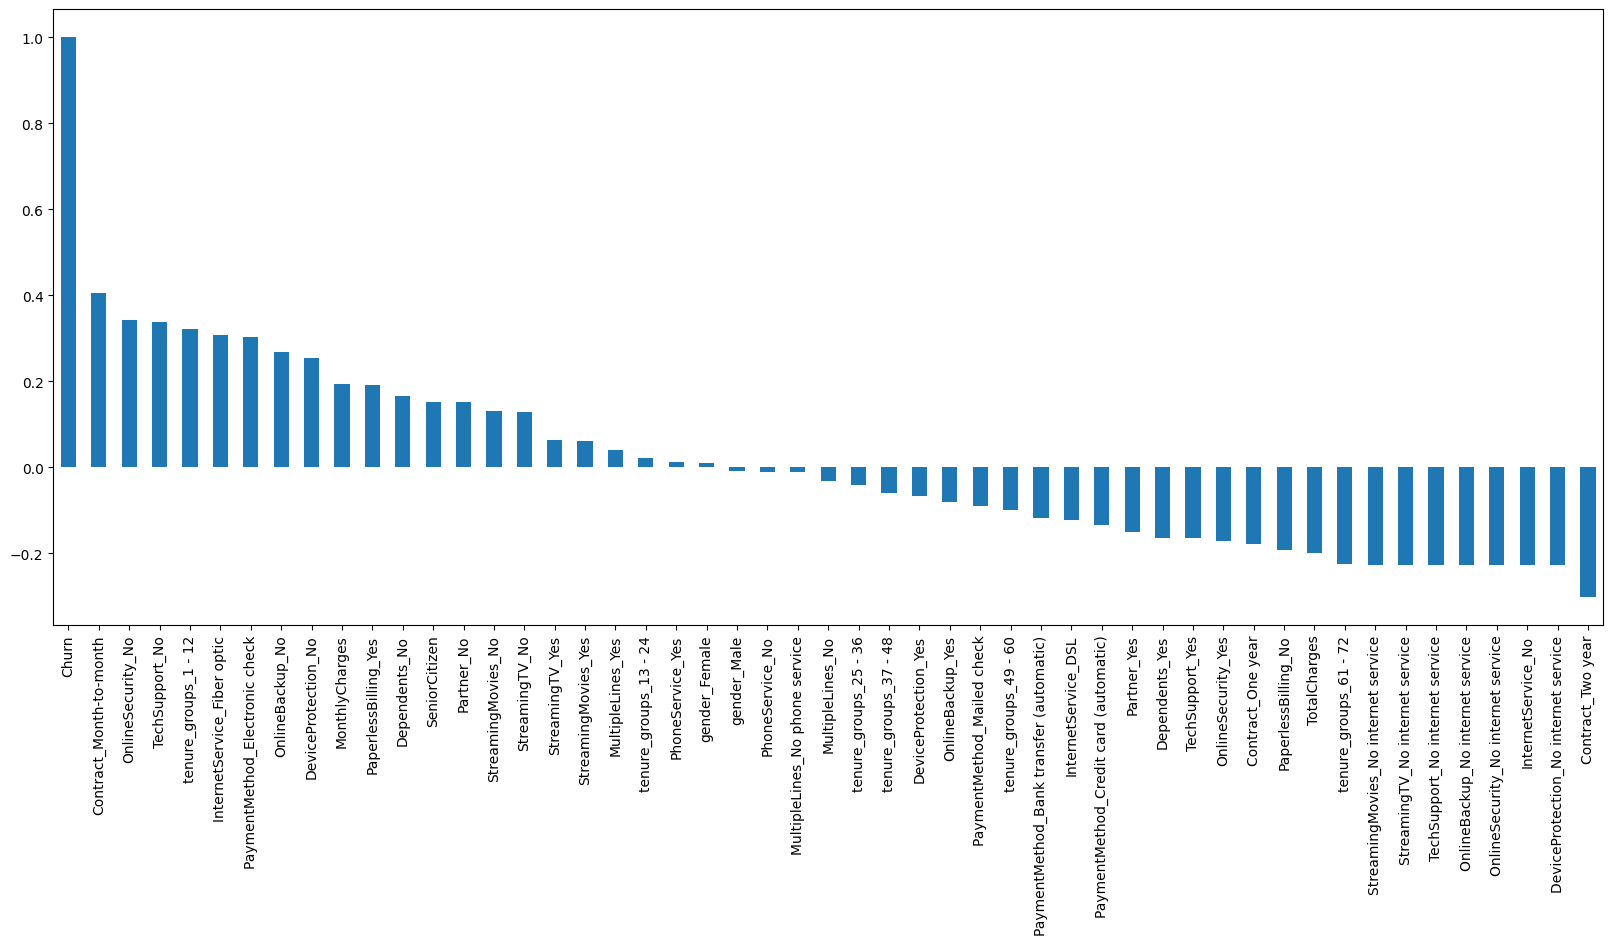

In [ ]:
plt.figure(figsize=(20,8))
telco_df_dummies.corr()["Churn"].sort_values(ascending=False).plot(kind='bar')

High Churn seen in case of Month to Month contracts, No online seurity , No Tech Support, First year of subscription and fibre optics internet.

Low Churn is seen in case of Long Term Contracts , Subscriptions without internet service and the customers engaged for 5+ years.

Factors like gender, availibilty of phone service, and number of multiple lines have almost no impact on Churn.

Lets take a look into a heatmap as well

<Axes: >

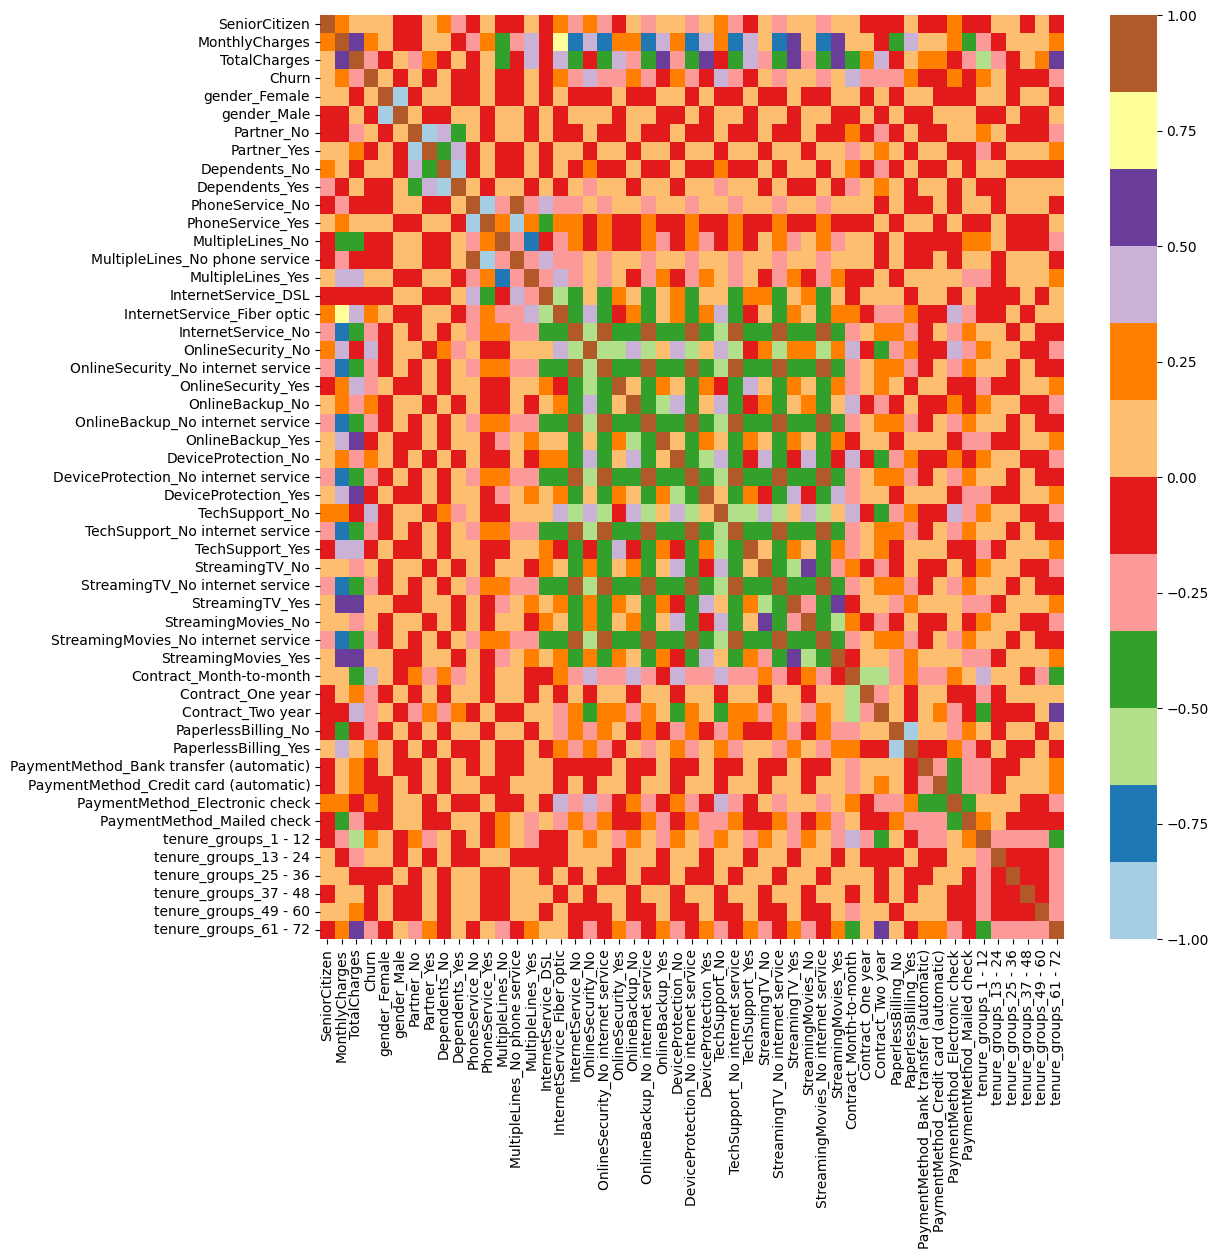

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(telco_df_dummies.corr(), cmap="Paired")

#Bivariate Analysis

In [ ]:
#Making 2 new dataframes one where we consider churn = 0 and the other where we consider churn = 1
new_df2_c0 = telco_df2.loc[telco_df2['Churn'] == 0]
new_df2_c1 = telco_df2.loc[telco_df2['Churn'] == 1]

In [ ]:
#Creating a function uniplot to plot any 2 general variables

def uniplot(df,col,title,hue=None):
  sns.set_style('whitegrid') #makes default style of the plot
  sns.set_context('talk')
  plt.rcParams["axes.labelsize"] = 20 #rcparams used to customize default behavior of matplotlib ie font size, figure size....
  plt.rcParams["axes.titlesize"] = 22
  plt.rcParams["axes.titlepad"] = 30

  temp = pd.Series(data = hue)
  fig, ax = plt.subplots()
  width = len(df[col].unique()) + 7 + 4*len(temp.unique())
  fig.set_size_inches(width , 8)
  plt.xticks(rotation=45)
  plt.yscale('log')
  plt.title(title)
  ax = sns.countplot(data = df, x = col , order = df[col].value_counts().index, hue = hue, palette = 'bright')
  plt.show()


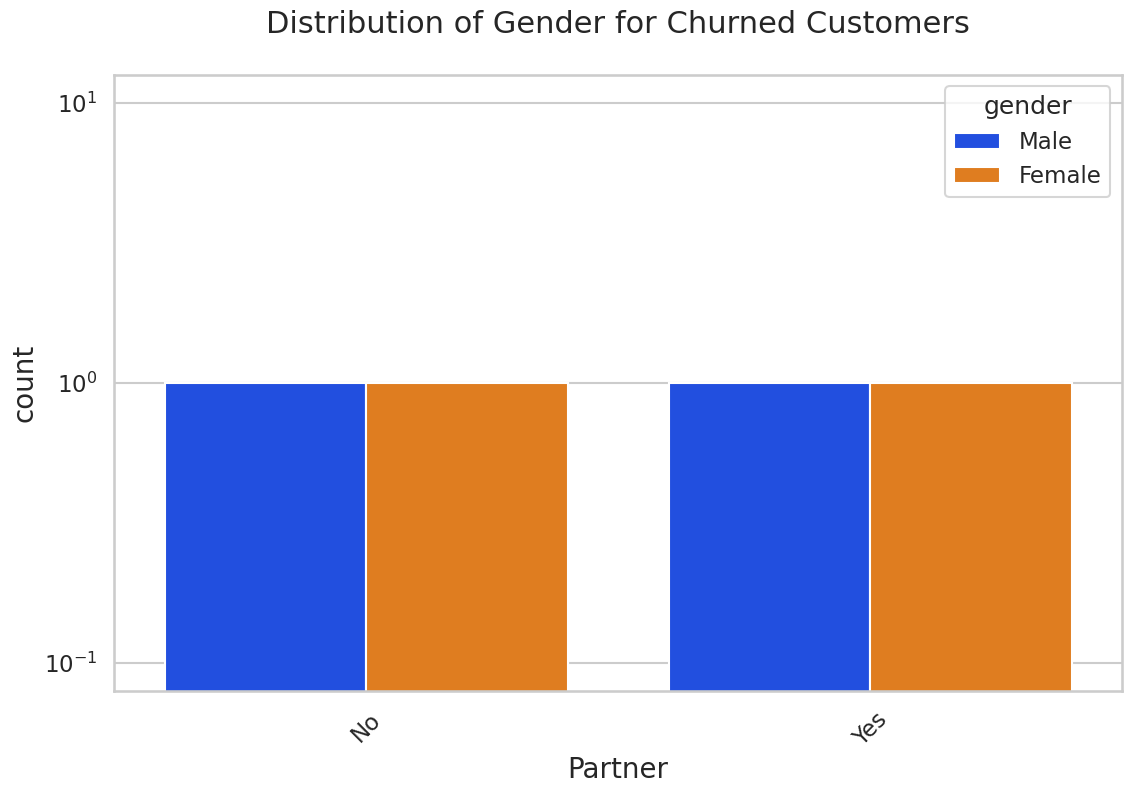

In [ ]:
#Bivariate of Count Churned, Partner with gender
uniplot(new_df2_c1, col='Partner', title = 'Distribution of Gender for Churned Customers' , hue = 'gender')

People who dont have any partners are more likely to churn . Also male or female doesnt seem to affect the churn a lot.

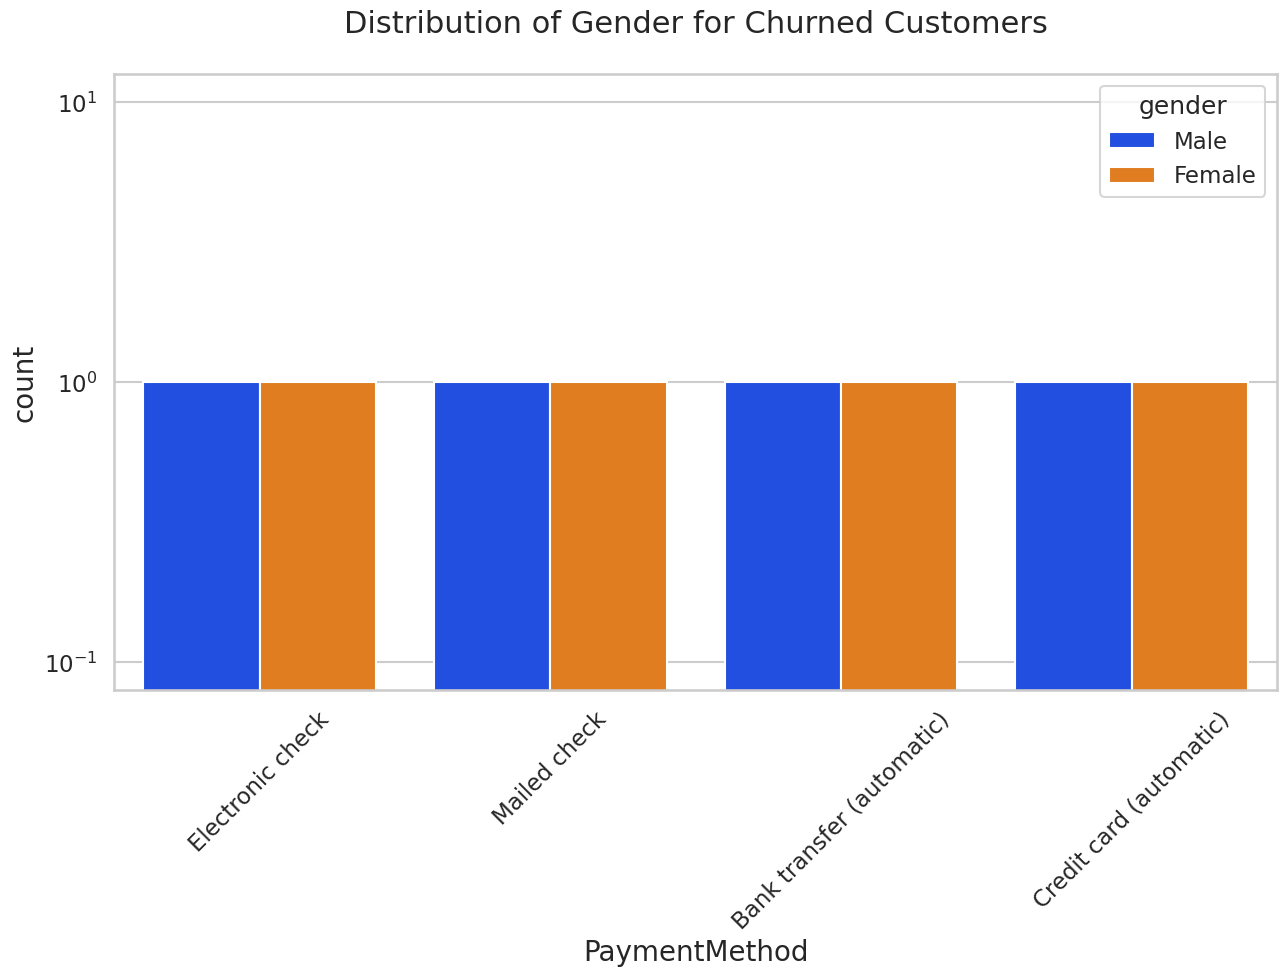

In [ ]:
uniplot(new_df2_c1, col='PaymentMethod', title = 'Distribution of Gender for Churned Customers' , hue = 'gender')

People using E-Check as a method of payment are more likely to churn. Also Females using Credit Card(automatic) are more likely to churn when compared to men.

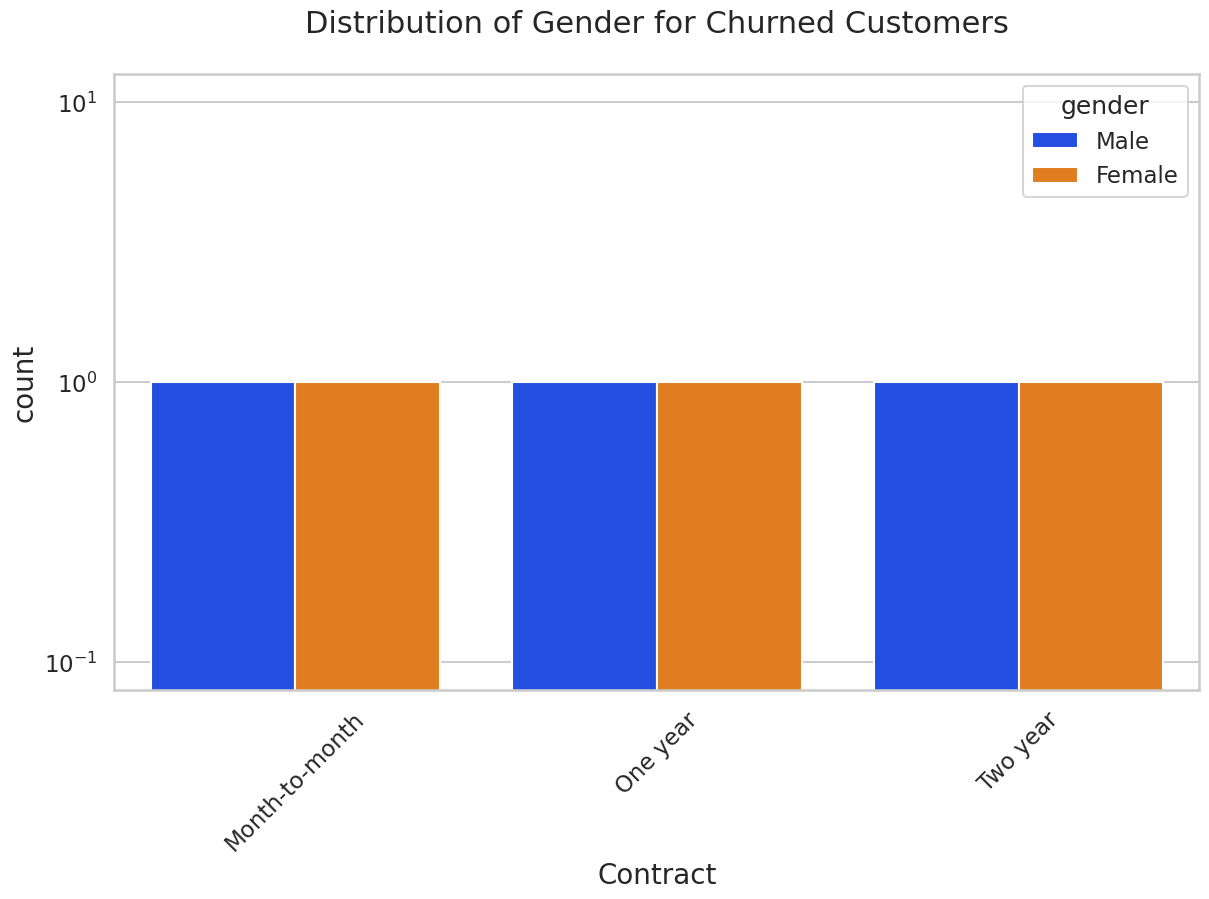

In [ ]:
uniplot(new_df2_c1, col='Contract', title = 'Distribution of Gender for Churned Customers' , hue = 'gender')

Being male or female doesnt seem to affect Churn in various contracts. Also people who have their contracts on a month to month basis are more likely to churn.

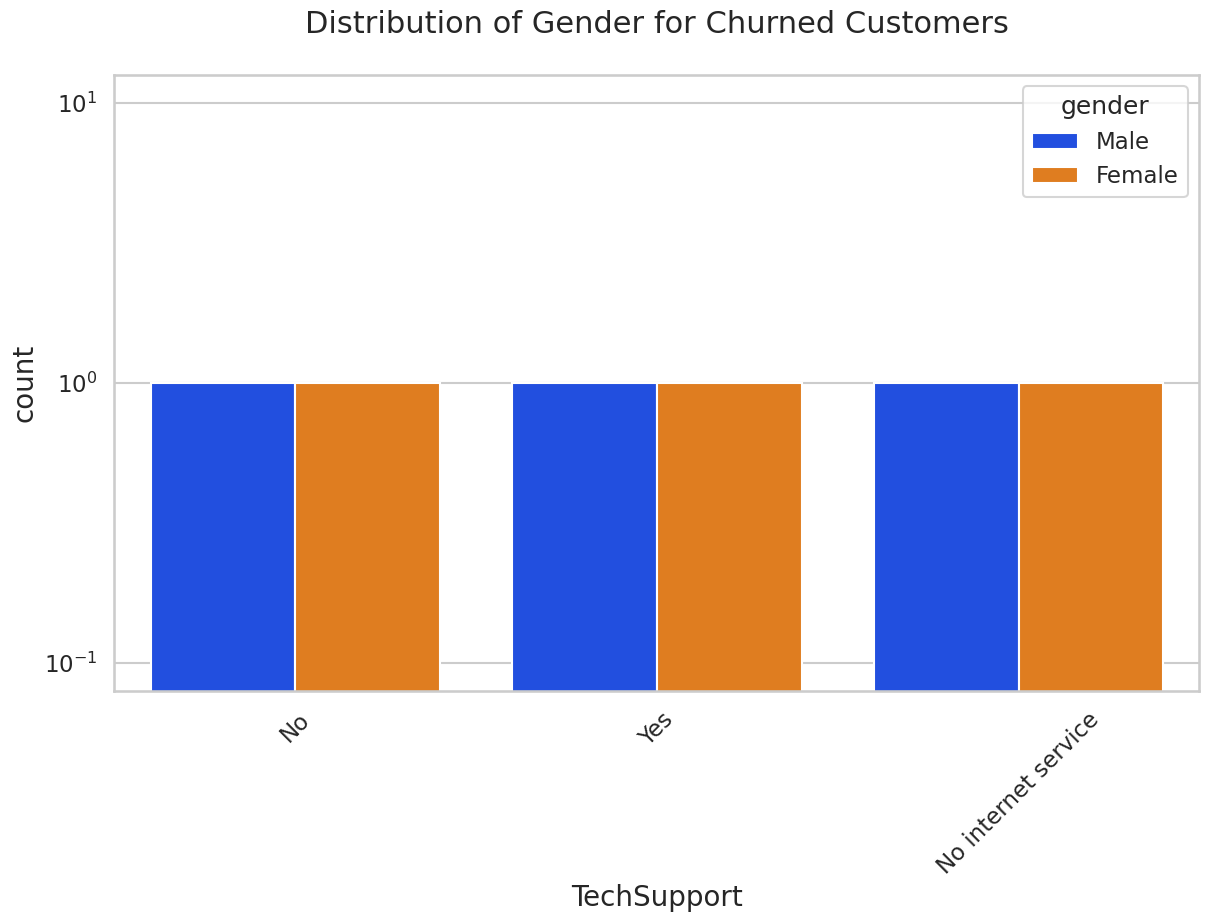

In [ ]:
uniplot(new_df2_c1, col='TechSupport', title = 'Distribution of Gender for Churned Customers' , hue = 'gender')

Its obvious that people who didnt receive Tech Support are more likely to churn

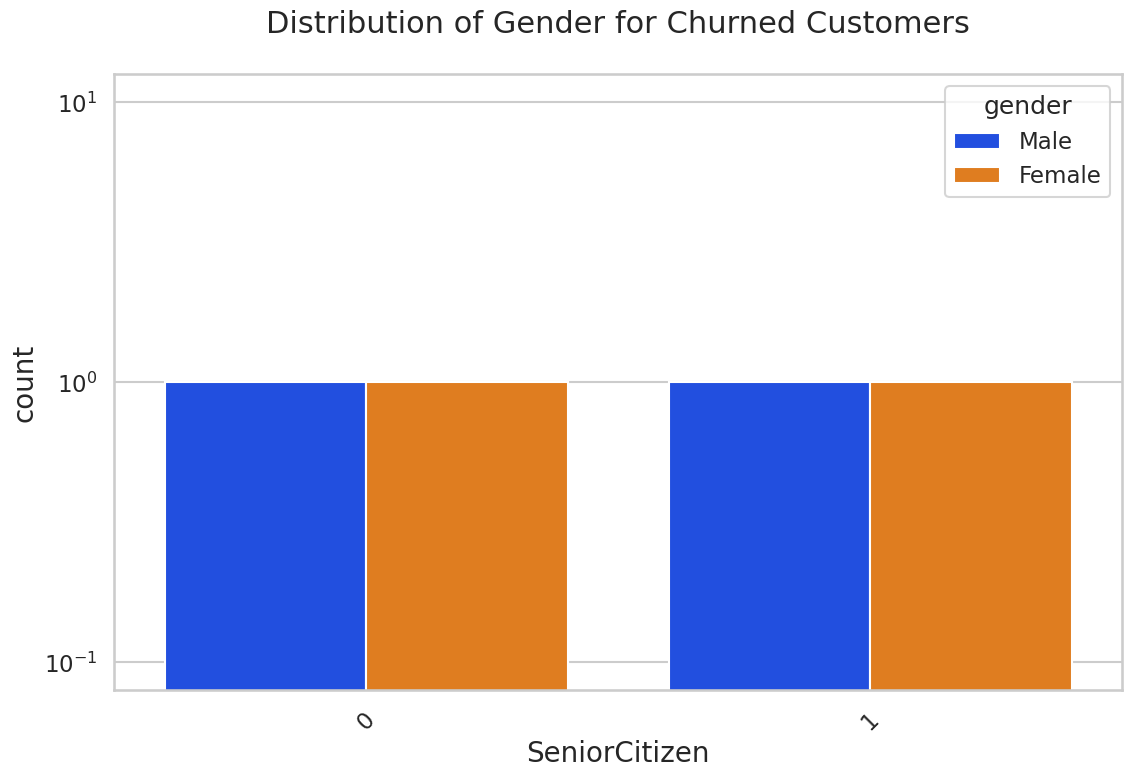

In [ ]:
uniplot(new_df2_c1, col='SeniorCitizen', title = 'Distribution of Gender for Churned Customers' , hue = 'gender')

We can see that Senior Citizens are less likely to Churn and Gender doesnt play any part here

# Final Conclusion based on above analysis.

1. Electronic check medium are the highest churners
2.Contract Type-Monthly customers are more likely to churn because of no contract terms as they are free to go customers.
3.No online security. No tech support category are high churners.
4.Non senior citizens are high churners.

In [ ]:
telco_df_dummies.to_csv('tel_churn.csv')